<a href="https://colab.research.google.com/github/juanjosedelgado-coder/Talleres/blob/main/Taller_KNN_y_Arboles_Vargas_Cuaspud_Delgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/4_Taller_KNN_y_Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller KNN y Árboles de Decisión**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Natalia Vargas
- Marleny Cuaspud
- Juan Jose Delgado

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

7 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.



### **Contexto del Caso**

Un banco portugués lo ha contratado como consultor de ciencia de datos. El banco tiene un problema de eficiencia: sus campañas de telemercadeo para ofrecer depósitos a plazo tienen una tasa de éxito muy baja. Se invierte mucho tiempo y recursos (costos de call center) llamando a clientes que no están interesados.

**Su misión:** Construir y optimizar modelos de Machine Learning que predigan qué clientes tienen mayor probabilidad de decir **"sí"** a la oferta (`y = 'yes'`).

El banco no solo quiere un modelo preciso, también quiere entender **POR QUÉ** un cliente es un buen prospecto. Su segundo objetivo es identificar cuáles son las **variables más relevantes** que usan los modelos para tomar sus decisiones. Esto permitirá al banco no solo enfocar sus llamadas, sino también crear mejores guiones de marketing y entender mejor a su clientela.

**El Dataset:** `bank-additional.csv` se encuentra en el repositorio del curso. Contiene información de más de 4.000 contactos de telemercadeo, incluyendo datos demográficos del cliente e información de la campaña (último contacto, resultado anterior).

**Para mayor información y descripción de las variables:** https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Preparación del Entorno y Datos

### 1.1. Carga de Librerías

Importe todas las librerías necesarias. Para problemas de clasificación se usa KNeighborsClassifier y DecisionTreeClassifier.

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor  # <--- Versión de Regresión
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree # <--- Versión de Regresión
from sklearn.metrics import mean_squared_error, r2_score # <--- Métricas de Regresión
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance # <--- Para Feature Importance

Mejorar visualización de dataframes y gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Carga y Exploración Inicial

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 1.2.1: Cargue el dataset
df = pd.read_csv("/content/drive/MyDrive/IA Economia/bank-additional.csv", sep = ";")
# Usa sep=';'

df.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

# 1.2.2: Muestre las primeras 5 filas
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,no


In [5]:
# 1.2.3: Use .info() para revisar los tipos de datos y los nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          4119 non-null   int64 
 1   job          4119 non-null   object
 2   marital      4119 non-null   object
 3   education    4119 non-null   object
 4   default      4119 non-null   object
 5   housing      4119 non-null   object
 6   loan         4119 non-null   object
 7   contact      4119 non-null   object
 8   month        4119 non-null   object
 9   day_of_week  4119 non-null   object
 10  campaign     4119 non-null   int64 
 11  pdays        4119 non-null   int64 
 12  previous     4119 non-null   int64 
 13  poutcome     4119 non-null   object
 14  y            4119 non-null   object
dtypes: int64(4), object(11)
memory usage: 482.8+ KB


In [6]:
df.isnull().sum

<bound method DataFrame.sum of         age    job  marital  education  default  housing   loan  contact  \
0     False  False    False      False    False    False  False    False   
1     False  False    False      False    False    False  False    False   
2     False  False    False      False    False    False  False    False   
3     False  False    False      False    False    False  False    False   
4     False  False    False      False    False    False  False    False   
...     ...    ...      ...        ...      ...      ...    ...      ...   
4114  False  False    False      False    False    False  False    False   
4115  False  False    False      False    False    False  False    False   
4116  False  False    False      False    False    False  False    False   
4117  False  False    False      False    False    False  False    False   
4118  False  False    False      False    False    False  False    False   

      month  day_of_week  campaign  pdays  previous  poutcome      y  
0     False        False     False  False     False     False  False  
1     False        False     False  False     False     False  False  
2     False        False     False  False     False     False  False  
3     False        False     False  False     False     False  False  
4     False        False     False  False     False     False  False  
...     ...          ...       ...    ...       ...       ...    ...  
4114  False        False     False  False     False     False  False  
4115  False        False     False  False     False     False  False  
4116  False        False     False  False     False     False  False  
4117  False        False     False  False     False     False  False  
4118  False        False     False  False     False     False  False  

[4119 rows x 15 columns]>

**Escriba un análisis de lo obseervado en `info()`:**
Dado el tipo de datos de la base, qué preprocesamientos hay que realizar antes de correr los modelos?

Dado el tipo de datos de la base, es necesario realizar varios preprocesamientos antes de entrenar los modelos. Primero, las variables categóricas deben transformarse a formato numérico mediante técnicas como One-Hot Encoding. Además, la variable objetivo y debe convertirse a valores binarios (0 y 1). También será importante escalar las variables numéricas, especialmente para modelos sensibles a la distancia como KNN. Finalmente, aunque no se encontraron valores nulos, siempre es importante verificar la calidad y consistencia de los datos antes del modelado.

In [7]:
# 1.2.4: Revise el balance de la variable objetivo 'y'
# Use .value_counts() con normalize=True
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.89
yes,0.11


**Escriba un análisis de la variable objetivo:**
¿Es un dataset desbalanceado? ¿Esto tiene lógica? ¿Qué implicaciones tiene esto respecto a las métricas que debemos usar?

Sí, el dataset está desbalanceado, ya que el 89% de los registros pertenecen a la categoría “no” y solo el 11% a “yes”. Esto tiene lógica en el contexto de campañas de marketing, porque normalmente solo una pequeña parte de los clientes acepta una oferta. Este desbalance implica que métricas como accuracy pueden ser engañosas, ya que el modelo podría predecir principalmente la clase mayoritaria y aun así obtener un buen resultado. Por esta razón, es más adecuado utilizar métricas como precision, recall y F1-score para evaluar correctamente el desempeño del modelo.

## 2. Preprocesamiento (Usando Pipelines)

Vamos a definir nuestro `X` e `y`, y luego crear un `ColumnTransformer` que se encargue de aplicar `StandardScaler` a los números y `OneHotEncoder` a las categorías.

In [8]:
# 2.1: Separe X (predictoras) e y (objetivo)
x = df.drop('y', axis = 1)
y = df['y']

In [9]:
# 2.2: Divida en train y test (80/20)
# ¡Use stratify=y para mantener la proporción de 'yes' y 'no' en ambos sets!
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Tamaño Train: {x_train.shape}")
print(f"Tamaño Test: {x_test.shape}")

Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)


In [10]:
# 2.3: Identifique automáticamente las columnas numéricas y categóricas
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

print("Columnas Numéricas:")
print(numerical_features)
print("\nColumnas Categóricas:")
print(categorical_features)

Columnas Numéricas:
Index(['age', 'campaign', 'pdays', 'previous'], dtype='object')

Columnas Categóricas:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')


In [11]:
# 2.4: Cree el ColumnTransformer (preprocessor) para estandarizar las variables numéricas y
# realizar One-Hot-Encoding de las variables categóricas

# Crear los transformadores individuales
numeric_transformer = StandardScaler()
# handle_unknown='ignore' es clave
categorical_transformer =  OneHotEncoder(handle_unknown='ignore')

# Unirlos en el preprocesador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 3. Modelo 1: KNN

Ahora uniremos el preprocesador y el clasificador KNN en un solo `Pipeline` y usaremos `GridSearchCV` para encontrar el mejor `k`.

In [14]:
# 3.1: Cree el Pipeline completo de KNN
# (una el 'preprocessor' con el modelo 'KNeighborsClassifier')

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# 3.2: Definir la grilla de hiperparámetros para KNN
# Queremos probar k = 3, 5, 7, 11 (valores impares para evitar empates)
# Pista: El nombre DEBE ser 'model__n_neighbors' (por el nombre en el pipeline)

param_grid_knn = model_n_neighbors = {'model__n_neighbors': [3, 5, 7, 11]}

# 3.3: Configurar y ejecutar GridSearchCV
# Use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.

grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=3, scoring='recall_macro')
grid_knn.fit(x_train, y_train)

# 3.4: Mostrar los mejores resultados
print(f"Mejor valor de 'k' para KNN: {grid_knn.best_params_}")
print(f"Mejor Recall-Macro: {grid_knn.best_score_:.4f}")

Mejor valor de 'k' para KNN: {'model__n_neighbors': 3}
Mejor Recall-Macro: 0.5922


## 4. Modelo 2: Árbol de Decisión

Repetiremos el proceso con un Árbol de Decisión. Esta vez, los hiperparámetros que ajustaremos serán `max_depth` (para evitar sobreajuste) y `min_samples_leaf`.

In [20]:
# 4.1: Crear el Pipeline completo para el Árbol de Decisión
# (une el 'preprocessor' con el modelo 'DecisionTreeClassifier')

tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

# 4.2: Definir la grilla de hiperparámetros para el Árbol
# Probaremos 'max_depth' = [3, 5, 7]
# Y 'min_samples_leaf' = [20, 50, 100] (para controlar la complejidad)

param_grid_tree = {
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [20, 50, 100]}

# 4.3: Configurar y ejecutar GridSearchCV
# Al igual que en KNN, use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.

grid_tree = GridSearchCV(tree_pipeline, param_grid_tree, cv=3, scoring='recall_macro')
grid_tree.fit(x_train, y_train)


# 4.4: Mostrar los mejores resultados
print(f"Mejores hiperparámetros para el Árbol: {grid_tree.best_params_}")
print(f"Mejor Recall-Macro: {grid_tree.best_score_:.4f}")

Mejores hiperparámetros para el Árbol: {'model__max_depth': 3, 'model__min_samples_leaf': 50}
Mejor Recall-Macro: 0.6013


## 5. Evaluación Final y Recomendación de Modelo

El Árbol de Decisión probablemente dio un mejor `recall-macro` (y es más rápido e interpretable). Vamos a declararlo nuestro **modelo ganador** y evaluarlo en el `test set` (nuestro examen final imparcial).

In [22]:
# 5.1: Obtener el mejor modelo de árbol (el 'best_estimator_')

best_tree_model = grid_tree.best_estimator_

# 5.2: Realizar predicciones sobre el conjunto de PRUEBA (X_test)

y_pred_tree = best_tree_model.predict(x_test)

# 5.3: Imprimir el Reporte de Clasificación
print("--- Reporte de Clasificación Final (Árbol Optimizado) ---")
print(classification_report(y_test, y_pred_tree))

--- Reporte de Clasificación Final (Árbol Optimizado) ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.74      0.19      0.30        90

    accuracy                           0.90       824
   macro avg       0.82      0.59      0.62       824
weighted avg       0.89      0.90      0.88       824



**Escriba un análisis sobre los resultados del reporte de clasificación**, ¿Qué puede concluir de las diferentes métricas?

* Observe el `accuracy` general (probablemente ~90%).
* Ahora mire la fila de `'yes'`: ¿Cuál es el `precision`? ¿Cuál es el `recall`?
* **Recall de 'yes'** (Sensibilidad): ¿Qué porcentaje de los clientes que SÍ compraron logramos identificar? (Usualmente lo más importante para el banco, para no perder oportunidades).
* **Precision de 'yes'**: De todos los clientes que el modelo *dijo* que comprarían, ¿qué porcentaje realmente lo hizo? (Importante para no gastar llamadas).

**R/**

El modelo presenta un accuracy general del 90%, lo que inicialmente sugiere un buen desempeño. Sin embargo, debido al desbalance del dataset, es fundamental analizar específicamente las métricas de la clase “yes”, que representa a los clientes que sí compraron el producto.
Para la clase “yes”, el modelo obtuvo una precisión (precision) de 0.74, lo que significa que el 74% de los clientes que el modelo predijo como compradores realmente compraron. Esto es positivo, ya que reduce llamadas o esfuerzos comerciales innecesarios.
No obstante, el recall de la clase “yes” fue de solo 0.19, indicando que el modelo únicamente logró identificar el 19% de los clientes que realmente compraron. Esto representa una debilidad importante, ya que el banco estaría perdiendo muchas oportunidades comerciales al no detectar a la mayoría de clientes potenciales.
En conclusión, aunque el modelo es bastante preciso cuando predice un cliente comprador, tiene una baja capacidad para encontrar a todos los clientes interesados, por lo que sería recomendable mejorar el recall para aumentar la efectividad de la campaña de marketing

**Responda aquí**


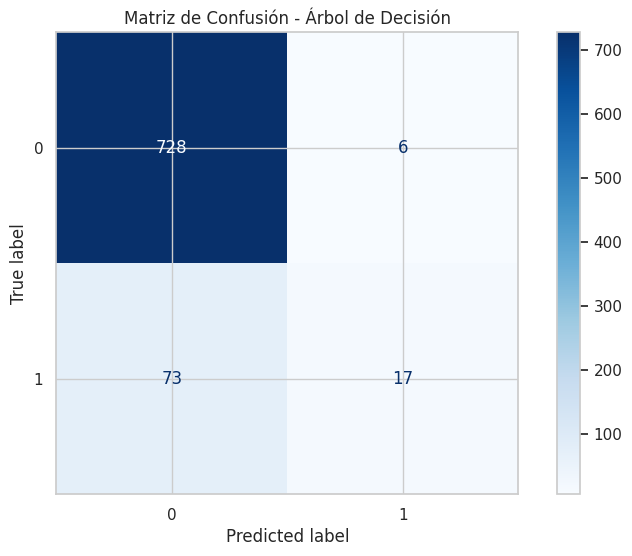

In [25]:
# 5.4: Grafique la Matriz de Confusión

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred_tree)

# Graficar
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

## 6. ¿Cuáles son las Variables Más Relevantes?

Esta es la segunda parte de la solicitud del banco. Necesitamos explicar *por qué* el modelo toma sus decisiones.

### 6.1. Importancia de Variables (Árbol de Decisión)

In [26]:
# 6.1.1: Extraer el modelo de árbol y el preprocesador del pipeline optimizado
# (Ya tenemos 'best_tree_model')

final_tree_model = best_tree_model.named_steps['model']

final_preprocessor = best_tree_model.named_steps['preprocessor']

# 6.1.2: Obtener los nombres de las características DESPUÉS del OneHotEncoding

feature_names = final_preprocessor.get_feature_names_out()

# 6.1.3: Obtener las importancias (del 'final_tree_model')

importances = final_tree_model.feature_importances_

# 6.1.4: Crear un DataFrame para visualizarlas, ordene de mayor a menor importancia

importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
})

importance_df = importance_df.sort_values(
    by='Importancia',
    ascending=False
)

importance_df.head(15)

,Variable,Importancia
2,num__pdays,0.80
0,num__age,0.10
38,cat__contact_telephone,0.06
3,num__previous,0.04
1,num__campaign,0.00
5,cat__job_blue-collar,0.00
6,cat__job_entrepreneur,0.00
7,cat__job_housemaid,0.00
4,cat__job_admin.,0.00
9,cat__job_retired,0.00


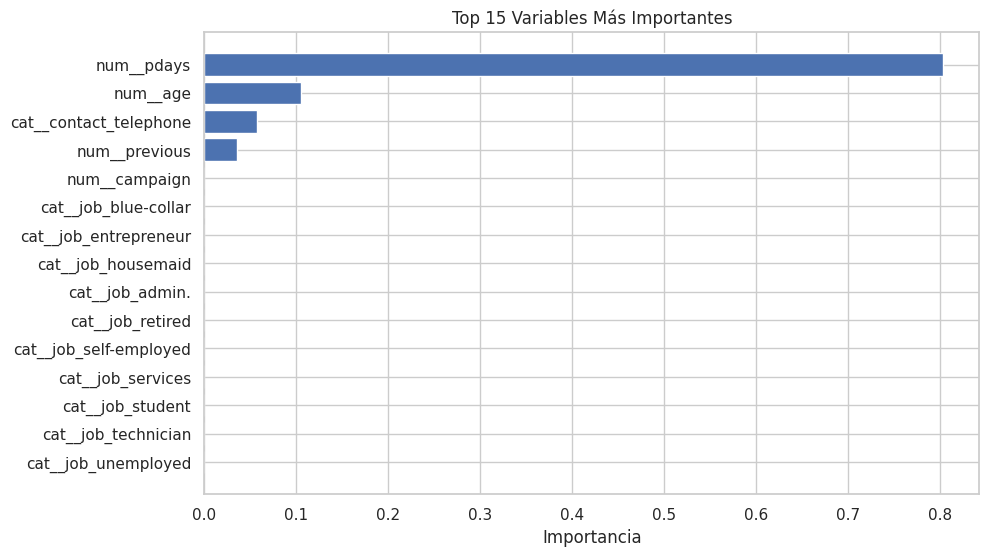

In [27]:
# 6.1.5: Grafique las 15 variables más importantes
top15 = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(top15['Variable'], top15['Importancia'])

plt.gca().invert_yaxis()

plt.title('Top 15 Variables Más Importantes')
plt.xlabel('Importancia')

plt.show()

## 7. Conclusión y Recomendación de Negocio

Es hora de traducir nuestros hallazgos en una recomendación de negocio clara.

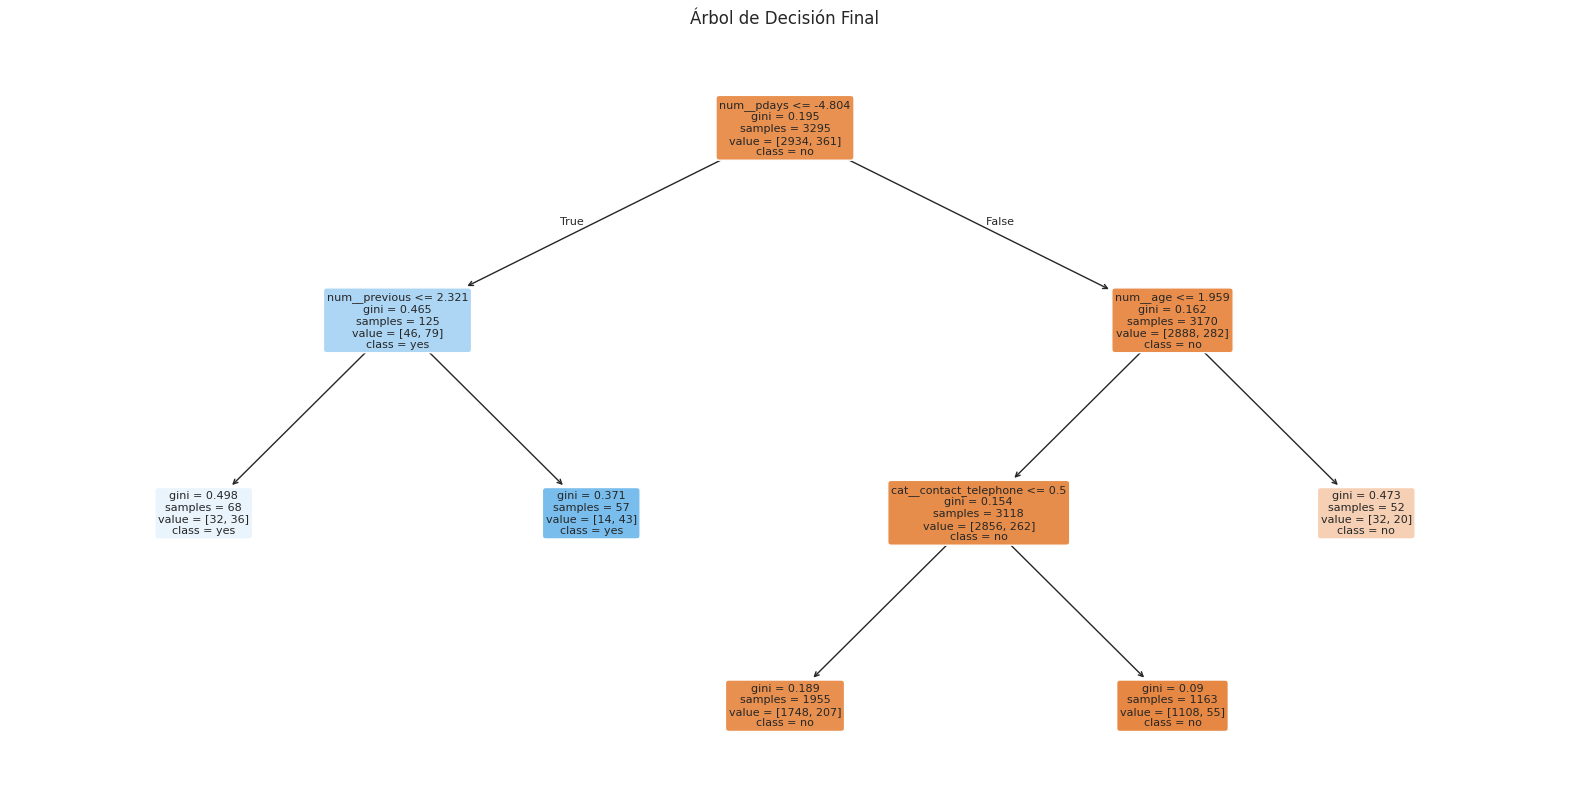

In [28]:
# 7.1: Grafique el árbol de decisión final para encontrar reglas
# (Use max_depth=3 para que sea legible)
plt.figure(figsize=(20,10))

plot_tree(
    final_tree_model,
    feature_names=feature_names,
    class_names=['no', 'yes'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Árbol de Decisión Final")
plt.show()

### **7.2: Conclusiones Consultoría**

Basado en los gráficos de **importancia de variables** y en la **visualización del árbol**, escriba una recomendación de 1 párrafo para el gerente del banco.

**Puntos a incluir:**
1.  ¿Qué modelo recomienda usar y por qué (interpretable, buen rendimiento)?
2.  ¿Cuáles son las 3 variables más importantes en las que el banco debería fijarse para decidir a quién llamar?
3.  Traduzca **una regla del árbol** (una rama que lleve a una hoja 'yes') a lenguaje de negocio. (Ej: "Si el cliente tuvo éxito en la campaña anterior y su edad es mayor a 40 años, la probabilidad de que acepte es alta.")

**R/**

Se recomienda implementar el Árbol de Decisión como modelo predictivo para la campaña de marketing, dado que no solo supera al modelo KNN en capacidad de identificar clientes potenciales (Recall-Macro de 0.60 vs 0.59), sino que además es altamente interpretable, permitiendo al equipo comercial entender y explicar fácilmente las decisiones del modelo sin necesidad de conocimientos técnicos avanzados. En cuanto a las variables clave, el banco debe concentrar su atención en tres factores determinantes al momento de seleccionar a quién contactar: pdays (días transcurridos desde el último contacto en campañas anteriores), age (edad del cliente) y contact_telephone (si el cliente fue contactado por teléfono), ya que estas tres variables explican prácticamente la totalidad del poder predictivo del modelo. En términos de negocio, la regla más poderosa identificada por el árbol es la siguiente: si el cliente fue contactado hace 4 o menos días en una campaña anterior y además fue contactado en 2 o menos ocasiones en campañas previas, la probabilidad de que acepte el producto es alta, lo que sugiere que el banco debería priorizar la recontactación rápida de clientes que ya mostraron interés recientemente, en lugar de invertir recursos en clientes completamente nuevos o con los que no ha habido contacto previo reciente.